# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [2]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [3]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [4]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [6]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [7]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [8]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [9]:
# Mostrar ejemplos de LabelEncoder
print("Codificación LabelEncoder:")
print(data[['sex', 'sex_label']].head())

# Mostrar columnas creadas con OneHotEncoder
print("\nColumnas OneHotEncoder:")
print(onehot_encoder.head())

Codificación LabelEncoder:
      sex  sex_label
0    male          1
1  female          0
2  female          0
3  female          0
4    male          1

Columnas OneHotEncoder:
   embarked_C  embarked_Q  embarked_S
0       False       False        True
1        True       False       False
2       False       False        True
3       False       False        True
4       False       False        True


LabelEncoder transforma categorías en números enteros, por ejemplo, puede convertir "male" en 1 y "female" en 0, lo cual es un método es simple, pero puede hacer que algunos modelos interpreten incorrectamente que existe un orden o jerarquía entre las categorías.

Por otro lado, OneHotEncoder crea una columna independiente para cada categoría posible, utilizando valores de 0 y 1 para indicar presencia o ausencia, esto evita introducir relaciones numéricas artificiales entre categorías y suele ser más adecuado para modelos de aprendizaje automático

### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

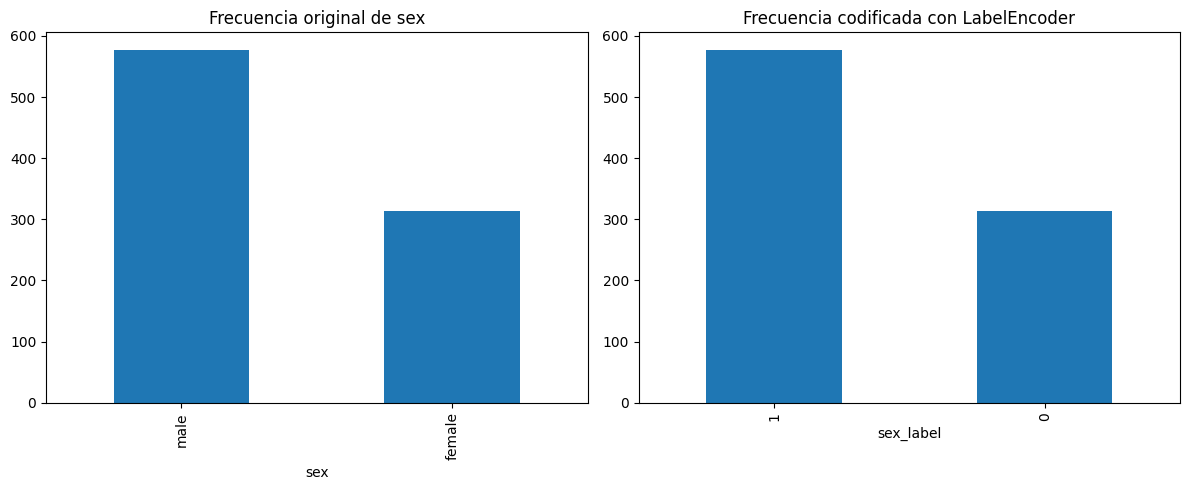

In [11]:
# Importar matplotlib
import matplotlib.pyplot as plt

# Crear figura
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Frecuencias originales
data['sex'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    title='Frecuencia original de sex'
)

# Frecuencias codificadas
data['sex_label'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    title='Frecuencia codificada con LabelEncoder'
)

# Mostrar gráficas
plt.tight_layout()
plt.show()

Las frecuencias se mantienen iguales antes y después de la codificación. La diferencia es que LabelEncoder transforma las categorías textuales en valores numéricos enteros para que puedan ser utilizadas por modelos de aprendizaje automático.

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [12]:
# Codificar columna 'class' usando OneHotEncoder con pandas
class_encoded = pd.get_dummies(data['class'], prefix='class')

# Mostrar resultados
print(class_encoded.head())

# Combinar con dataset original
data = pd.concat([data, class_encoded], axis=1)

# Mostrar columnas nuevas
print(data.head())

   class_First  class_Second  class_Third
0        False         False         True
1         True         False        False
2        False         False         True
3         True         False        False
4        False         False         True
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  ...  embark_town alive  alone sex_label  embarked_C  embarked_Q  \
0    man  ...  Southampton    no  False         1       False       False   
1  woman  ...    Cherbourg   yes  False         0        True       False   
2  woman  ...  Southampton   yes   True         0       Fals

Veo que se evita que el modelo interprete un orden numérico entre categorías, por ejemplo, con LabelEncoder podría interpretarse incorrectamente que “First” es mayor o mejor que “Second” y “Third”. 
En cambio, con OneHotEncoder se representa cada categoría de forma independiente utilizando columnas binarias, lo que suele ser mejor para variables categóricas nominales

### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

Para la mayoría de modelos de aprendizaje automático considero que elegiría OneHotEncoder para variables categóricas nominales, por que evita introducir relaciones numéricas artificiales entre categorías y esto ayuda a que el modelo interprete correctamente cada categoría como independiente.

Sin embargo, no dejaria de lado LabelEncoder por que puede ser útil en variables ordinales donde sí existe un orden natural entre categorías, o en algunos algoritmos específicos que pueden trabajar adecuadamente con variables codificadas numéricamente.